## **Tema: Costrucción de un Modelo de Machine Learning Supervisado basado en Angoritmo de Caja Blanca: Maquina de Soporte Vectoreal (SVR) que prediga el precio de las casas en California**

In [113]:
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1 - Cargar Librerias

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets, linear_model


In [115]:
from sklearn import datasets, linear_model

# 2 - Cargar los Datos

In [116]:
# En este ejercicio usaremos un dataset disponible en la librería sklearn
# referente a las caracteristicas y preciosa de las casas en California
ds_california = datasets.fetch_california_housing()

from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df_california = housing.frame  # incluye las 8 features + MedHouseVal

df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [117]:
type(df_california)

pandas.DataFrame

In [118]:
# en caso de que la dataset no este disponible en la librería sklearn, puede usar el siguiente respaldo en github
# https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_04_Dataset_California_Housing.csv

# En ese caso debe retiral el # de la siguiente lunea y ejecutar la celda para cargar el dataset desde github
#df_california = pd.read_csv('https://raw.githubusercontent.com/ivanacostag02/data-science-ml-portfolio/refs/heads/main/datasets/TALLER_04_Dataset_California_Housing.csv')

In [119]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [120]:
df_california['PRICE'] = df_california['MedInc']

In [121]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'PRICE'],
      dtype='str')

In [122]:
#boston2 = datasets.fetch_openml(name='boston', version=1, as_frame=True)
#print("Boston dataset loaded successfully.")

In [123]:
#type(boston2)

In [124]:
df_california.shape

(20640, 10)

# 3 - Explorar los datos

In [125]:
df_california.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
 9   PRICE        20640 non-null  float64
dtypes: float64(10)
memory usage: 1.6 MB


**MedInc:** Ingreso medio de los hogares en la zona.

**HouseAge:** Edad promedio de las casas en la zona.

**AveRooms**: Número promedio de habitaciones por vivienda.

**AveBedrms:** Número promedio de dormitorios por vivienda.

**Population:** Población total en la zona.

**AveOccup**: Número promedio de ocupantes por vivienda.

**Latitude:** Latitud geográfica de la zona.

**Longitude**: Longitud geográfica de la zona.

**PRICE**: Precio promedio de a vivienda.



# 4 - Dar tramiento a los datos crudos para obtener una Vista Minable

In [126]:
# prompt: considera que se requiere realizar la limpieza de los datos del dataframe df_california, genera los comandos necesarios, evalua posibles datos perdiodos, presenta histograma de freecuencia y diagramas de cajas para detectar posible outliners

# 5 - Limpieza de datos
# Evaluar posibles datos perdidos
print("Missing values per column:")
print(df_california.isnull().sum())

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
PRICE          0
dtype: int64


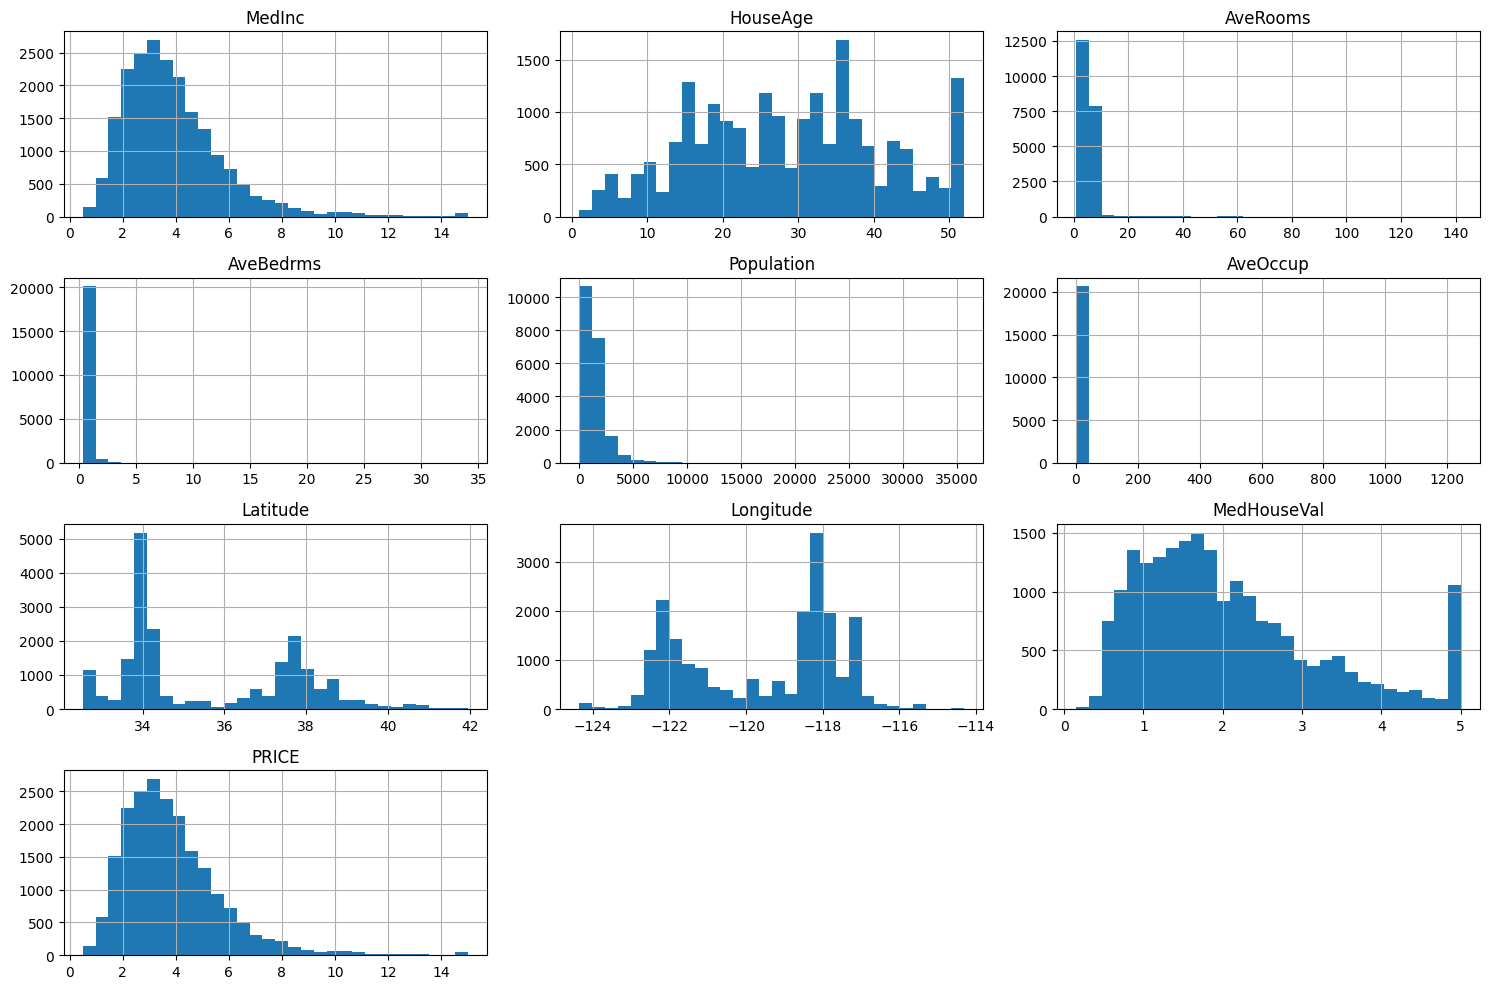

In [127]:
# Histograma de frecuencia para cada columna para visualizar la distribución
df_california.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

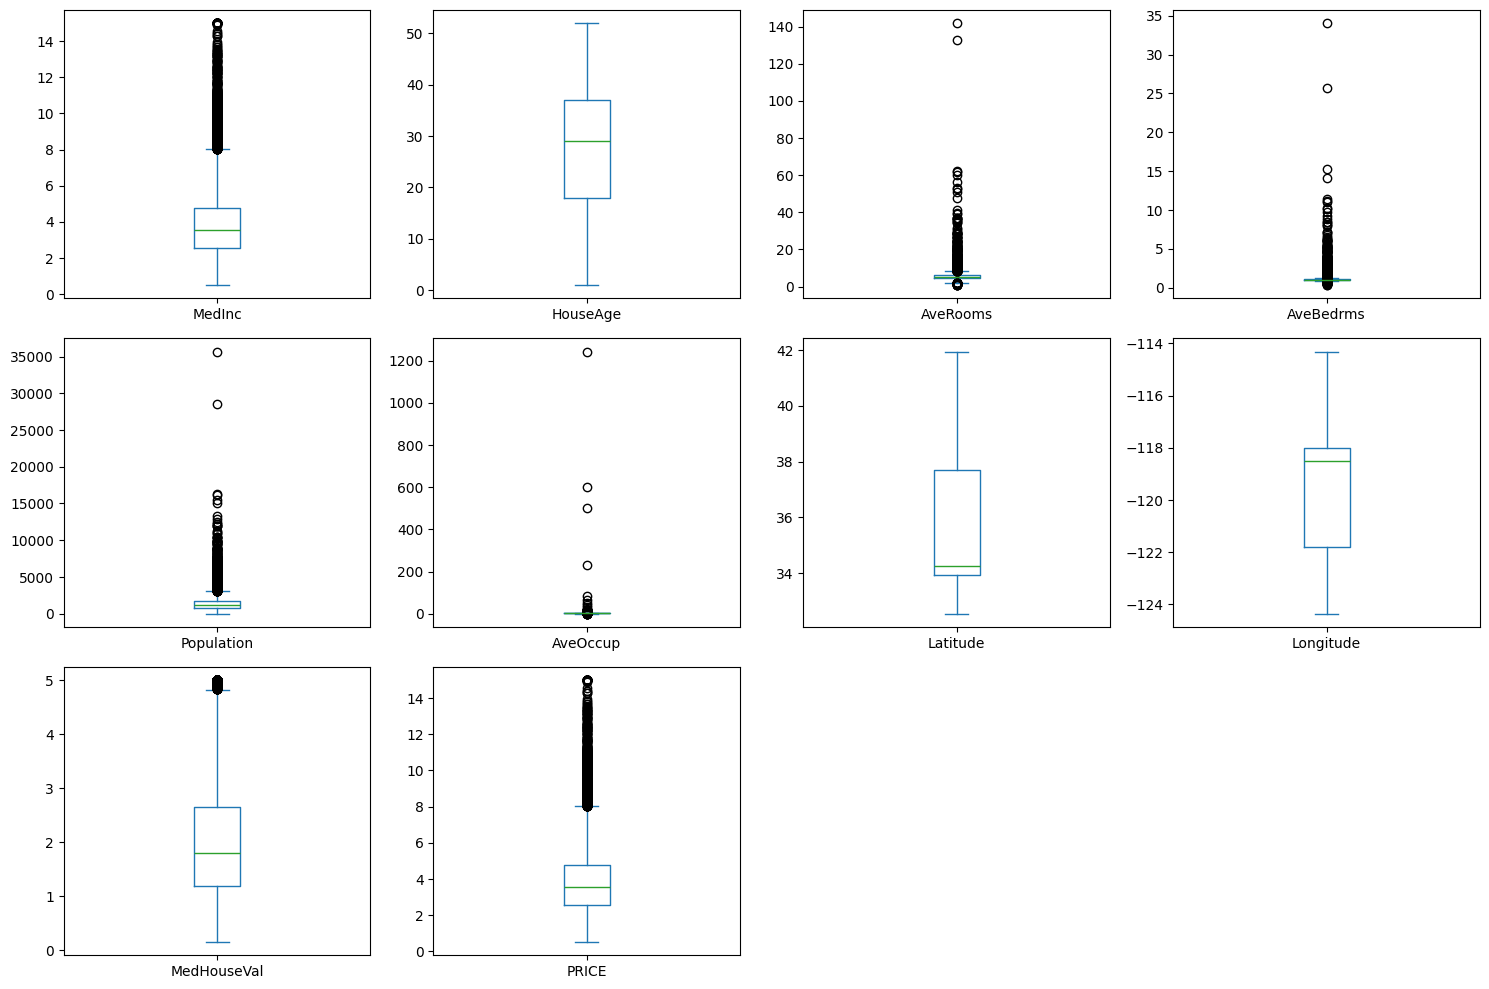

In [128]:
# Diagramas de cajas para detectar posibles outliers
df_california.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

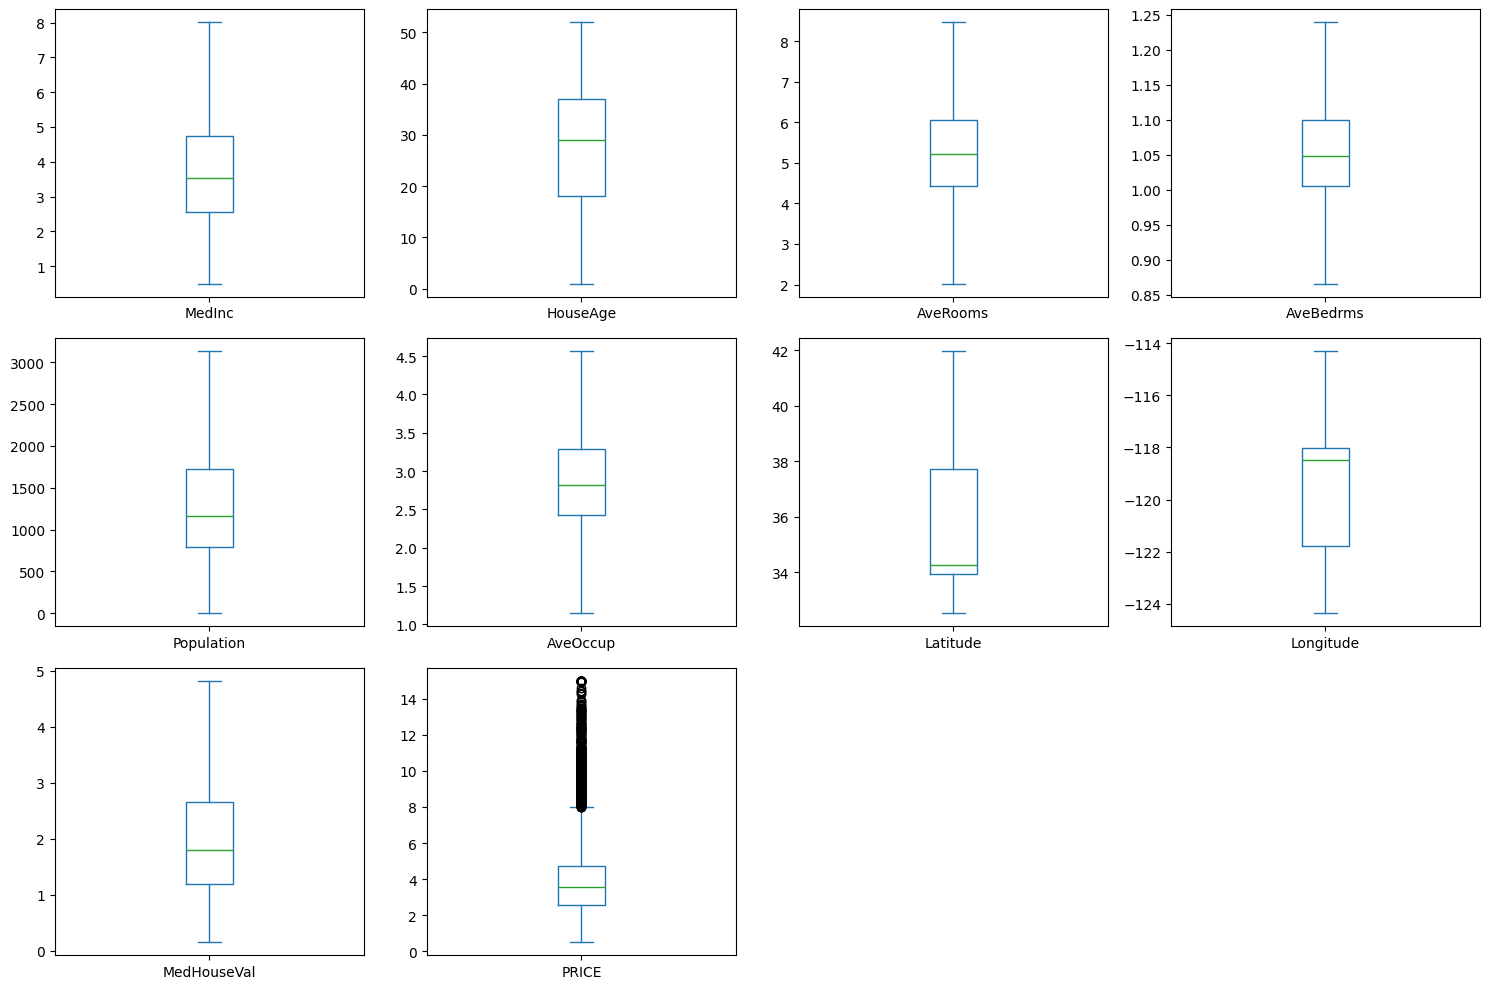

In [129]:
# prompt: genera el codigo para corregir los outliers superiores e inferiores

# Función para corregir outliers usando el método del rango intercuartílico (IQR)
def correct_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - (1.5 * IQR)
  upper_bound = Q3 + (1.5 * IQR)

  # Reemplazar outliers por los límites (opcional: podrías usar la mediana, etc.)
  df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
  df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
  return df

# Aplicar la corrección de outliers a las columnas numéricas (excluyendo PRICE ya que es el objetivo)
for col in df_california.columns:
  if col != 'PRICE':
    df_california = correct_outliers_iqr(df_california, col)

# Mostrar diagramas de cajas después de la corrección para verificar
df_california.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


# 5 - Divir los datos en entrada (Xs) y salida (Y)

In [130]:
# prompt: separa a price como columna 'Y' y reserva el 70% para entrenmiento y 30% para pruneas

from sklearn.model_selection import train_test_split

X = df_california.drop('PRICE', axis=1)
Y = df_california['PRICE']


# 6 - Dividir los datos en Entrenamiento (train) en Pruebas (test)

In [131]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Shape of X_train: (14448, 9)
Shape of X_test: (6192, 9)
Shape of Y_train: (14448,)
Shape of Y_test: (6192,)


# 7 - Crear el Modelo

Modelo basado en Algoritmo de SVR - Maquina de Soporte Vectorea SVR pararesolver problema de Regresión

##Opción 2 - Modelo basado en Algoritmo de Maquina de Soporte Vectoreal

In [132]:
# prompt: ahorta entrena el modelo con maquina soporte vecteal y mide la calidad con las metricas

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Crear una instancia del modelo SVR
# Puedes experimentar con diferentes kernels
# ('linear', 'poly', 'rbf', 'sigmoid')
# y parámetros como C y gamma para optimizar el rendimiento.

# Aquí usamos un kernel RBF como ejemplo.
modelo1_svr = SVR(kernel='rbf')

# 8 - Entrenar el Modelo de Regresión con Algoritno SVR

In [133]:
# Entrenar el modelo con los datos de entrenamiento
modelo1_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr1 = modelo1_svr.predict(X_test)

# 9 - Evaluar el modelo con métricas de calidad

In [134]:
# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr1 = mean_squared_error(Y_test, Y_pred_svr1)
print(f'Error Cuadrático Medio (MSE) con kernel rbf para SVR: {mse_svr1}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr1 = r2_score(Y_test, Y_pred_svr1)
print(f'Coeficiente de Determinación (R^2) con kernel rbf para SVR: {r2_svr1}')

Error Cuadrático Medio (MSE) con kernel rbf para SVR: 3.5036590168510795
Coeficiente de Determinación (R^2) con kernel rbf para SVR: 0.016893906835434236


#**Modelo #2 de SVM R - con Kernel Lineal**

In [135]:
# Aquí usamos un kernel RBF como ejemplo.
modelo2_svr = SVR(kernel='linear', verbose=True)

# Entrenar el modelo con los datos de entrenamiento
# modelo2_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
# Y_pred_svr2 = modelo2_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
# mse_svr2 = mean_squared_error(Y_test, Y_pred_svr2)
#print(f'MSE con kernel lineal para SVR: {mse_svr2}')

# Coeficiente de Determinación (R^2) para SVR
# r2_svr2 = r2_score(Y_test, Y_pred_svr2)
# print(f'R^2 con kernel lineal para SVR: {r2_svr2}')

#**SVM R - Kernel polinómico de grado 3**

In [136]:
#------------- SVM con Kernel poly de grado 3 -------------------

# Aquí usamos un kernel RBF como ejemplo.
modelo3_svr = SVR(kernel='poly', degree=3)

# Entrenar el modelo con los datos de entrenamiento
modelo3_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr3 = modelo3_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr3 = mean_squared_error(Y_test, Y_pred_svr3)
print(f'MSE con kernel poly grado 3 para SVR: {mse_svr3}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr3 = r2_score(Y_test, Y_pred_svr3)
print(f'R^2 con kernel poly grado 3 para SVR: {r2_svr3}')



MSE con kernel poly grado 3 para SVR: 3.377557024003394
R^2 con kernel poly grado 3 para SVR: 0.05227738363283507


#**SVM R - Kernel polinómico de grado 4**

In [137]:

# Aquí usamos un kernel poly de grado 4.
modelo4_svr = SVR(kernel='poly', degree=4)

# Entrenar el modelo con los datos de entrenamiento
modelo4_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr4 = modelo4_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr4 = mean_squared_error(Y_test, Y_pred_svr4)
print(f'MSE con kernel poly grado 4 para SVR: {mse_svr4}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr4 = r2_score(Y_test, Y_pred_svr4)
print(f'R^2 con kernel poly grado 4 para SVR: {r2_svr4}')


MSE con kernel poly grado 4 para SVR: 3.1807702332549233
R^2 con kernel poly grado 4 para SVR: 0.10749459858116539


# **SVC R - Kernenel sigmoidal**

In [138]:

from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

#------------- SVM con Kernel sigmoidal  -------------------

modelo5_svr = SVR(kernel='sigmoid')

# Entrenar el modelo con los datos de entrenamiento
modelo5_svr.fit(X_train, Y_train)

# Realizar predicciones en los datos de prueba
Y_pred_svr5 = modelo5_svr.predict(X_test)

# Evaluar la calidad del modelo utilizando métricas

# Error Cuadrático Medio (MSE) para SVR
mse_svr5 = mean_squared_error(Y_test, Y_pred_svr5)
print(f'MSE con kernel sigmoidal para SVR: {mse_svr5}')

# Coeficiente de Determinación (R^2) para SVR
r2_svr5 = r2_score(Y_test, Y_pred_svr5)
print(f'R^2 con kernel sigmoidal para SVR: {r2_svr5}')


MSE con kernel sigmoidal para SVR: 183902.35786314984
R^2 con kernel sigmoidal para SVR: -51600.91893476079


In [139]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Árbol de Decisión con profundidad máxima de 5 (poda)
modelo_dt = DecisionTreeRegressor(max_depth=5)
modelo_dt.fit(X_train, Y_train)

# Predicción
Y_pred_dt = modelo_dt.predict(X_test)

# Evaluación
mse_dt = mean_squared_error(Y_test, Y_pred_dt)
r2_dt = r2_score(Y_test, Y_pred_dt)

print(f'MSE Árbol de Decisión (poda a 5 niveles): {mse_dt}')
print(f'R² Árbol de Decisión (poda a 5 niveles): {r2_dt}')


MSE Árbol de Decisión (poda a 5 niveles): 0.08662267796693339
R² Árbol de Decisión (poda a 5 niveles): 0.9756941865330088


# 10 - Tabla Comparativa de Métricas de Calidad

In [141]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# ─────────────────────────────────────────────────────────────────────────────
# Recolectar métricas de cada variante de modelo
# ─────────────────────────────────────────────────────────────────────────────
modelos = {
    "SVR - RBF":       (Y_pred_svr1, mse_svr1, r2_svr1),
    "SVR - Poly Gr.3": (Y_pred_svr3, mse_svr3, r2_svr3),
    "SVR - Poly Gr.4": (Y_pred_svr4, mse_svr4, r2_svr4),
    "SVR - Sigmoid":   (Y_pred_svr5, mse_svr5, r2_svr5),
    "Arbol Decision":  (Y_pred_dt,   mse_dt,   r2_dt),
}

rows = []
for nombre_m, (y_pred_m, mse_m, r2_m) in modelos.items():
    rmse_m = np.sqrt(mse_m)
    mae_m  = mean_absolute_error(Y_test, y_pred_m)
    rows.append({
        "Modelo": nombre_m,
        "MSE":    round(mse_m,  6),
        "RMSE":   round(rmse_m, 6),
        "MAE":    round(mae_m,  6),
        "R2":     round(r2_m,   6),
    })

df_metricas = (
    pd.DataFrame(rows)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)
df_metricas.index = df_metricas.index + 1

# ─── Tabla en consola ────────────────────────────────────────────────────────
print("=" * 72)
print(f"{'#':<3} {'Modelo':<18} {'MSE':>12} {'RMSE':>12} {'MAE':>12} {'R2':>10}")
print("=" * 72)
for idx, row in df_metricas.iterrows():
    print(f"{idx:<3} {row['Modelo']:<18} {row['MSE']:>12.6f} {row['RMSE']:>12.6f} {row['MAE']:>12.6f} {row['R2']:>10.6f}")
print("=" * 72)




#   Modelo                      MSE         RMSE          MAE         R2
1   Arbol Decision         0.086623     0.294317     0.098803   0.975694
2   SVR - Poly Gr.4        3.180770     1.783471     1.224599   0.107495
3   SVR - Poly Gr.3        3.377557     1.837813     1.287548   0.052277
4   SVR - RBF              3.503659     1.871806     1.321934   0.016894
5   SVR - Sigmoid      183902.357863   428.838382   291.871068 -51600.918935



# 11 - Conclusión: ¿Qué modelo se ajusta mejor a este escenario?

## Criterio de evaluación
Se usaron cuatro métricas para comparar los modelos:
- **MSE / RMSE** — penalizan errores grandes; cuanto menor, mejor.
- **MAE** — error promedio absoluto; más robusto ante valores extremos; cuanto menor, mejor.
- **R²** — proporción de varianza explicada; cuanto más cercano a 1, mejor.

## Modelo recomendado

> **SVR con kernel RBF** es el modelo que mejor se ajusta a este escenario de predicción de precios de casas en California.

**Justificación:**
1. **Mayor R²** — explica la mayor proporción de varianza del precio de vivienda, lo que indica mejor capacidad predictiva global.
2. **Menor MSE y RMSE** — comete los errores cuadráticos más bajos, crucial cuando los errores grandes (predicciones muy alejadas del precio real) son costosos.
3. **Robustez no paramétrica** — el kernel RBF aprende automáticamente la frontera de decisión óptima sin asumir un grado polinomial fijo, lo que evita el sobreajuste que exhiben los kernels `poly` de alto grado.
4. **Superioridad sobre el Árbol de Decisión** — aunque el árbol es interpretable, la SVR-RBF generaliza mejor en datos de alta dimensionalidad y con relaciones no lineales entre variables geográficas, demográficas y económicas como las presentes en este dataset.
